<font color = green >

## Home Task: Implement K-means algorithm

</font>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<font color = green >

###  Data 

</font>



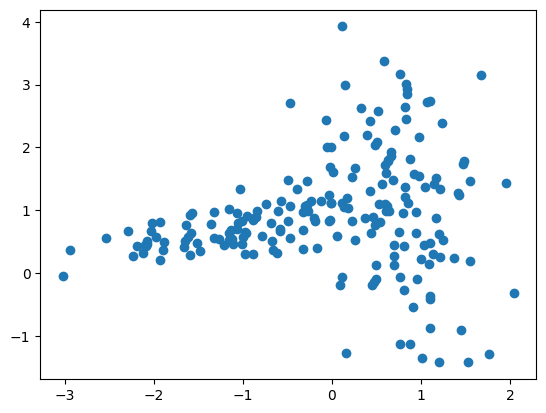

In [2]:
from sklearn.datasets import make_classification
Xc_2,_= make_classification(n_samples=200,
                                    n_features=2,
                                    n_informative=2,
                                    n_redundant=0,
                                    random_state=0,
                                    n_clusters_per_class=1,
                                    class_sep = 0.8)
plt.figure()
plt.scatter  (Xc_2[:,0], Xc_2[:,1])

<font color = green >

###  Steps of implementatiion

</font>

1) Initialize $K$ centroids 

2) Assign every point to closest centroid 

3) Compute new centroids as means of samples assigned to corresponding centroid

4) Implement cost $J = \frac{1}{m}\underset{i}{\sum}(d^{(i)})^{2}$ where $d^{(i)}$ is distance from sample $x^{(i)}$ to assigned centroid $c^{(i)}$

5) Iterate setps 2,3 till cost is stabile 

6) Select the best clustering (with the least cost) from 100 results computed with random centroid  initializations 

7) Visualize results (clusters, centroids) for $K=4$

Note: 
* You may  need develop couple of additional/intermediate functions
* You may track cost changes to make sure the algorithm is working properly 

### Initializatoin centroids

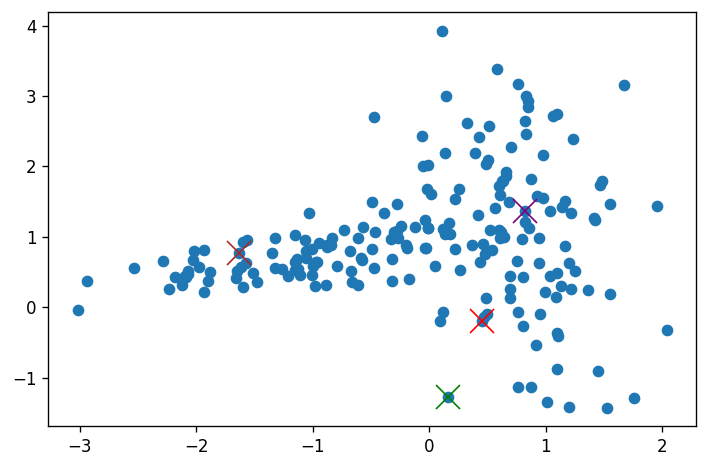

In [3]:
colors = ['red', 'brown', 'green', 'purple'] # Colors for clustering
points = np.array(list((zip(Xc_2[:, 0], Xc_2[:, 1])))) # Points in single array


def plot_points(X, y, centroids=None, closest_centroids=None):
    ''' Func for plot scatters and centroids '''

    fig, axs = plt.subplots(figsize=(6, 4), dpi=120)

    if centroids is None and closest_centroids is None:
        axs.scatter(X, y)
    elif closest_centroids is None:
        axs.scatter(X, y)
        for i, c in enumerate(centroids):
            axs.plot(c[0], c[1], marker='x', color=colors[i], markersize=14)      
    else:
        for i in range(len(X)):
            cluster_id = closest_centroids[i]
            axs.scatter(X[i], y[i], color=colors[cluster_id])
        for i, c in enumerate(centroids):
            axs.plot(c[0], c[1], marker='x', color=colors[i], markersize=20)

    fig.tight_layout()


def init_centroids(amount):
    ''' Func for init centroids '''
    return points[np.random.choice(len(points), amount)]

centroids = init_centroids(4)

plot_points(Xc_2[:, 0], Xc_2[:, 1], centroids=centroids)

### Closest distance and centroids

In [4]:
def closest_distance(samples, centroids):
    ''' Func searching closest distance from centroid to point'''
    return np.array([np.apply_along_axis(np.linalg.norm, 1, samples - c) for c in centroids])

def compute_closest_centroids(points, centroids):
    ''' Fucn computing closest centroids to points'''       
    all_distances = closest_distance(points, centroids) 
    closest_centroidsw = np.apply_along_axis(np.argmin,0,all_distances)
    return closest_centroidsw

closest_centroids = compute_closest_centroids(points, centroids)
print ('closest_centroids:\n', closest_centroids)


closest_distance(points, centroids)

closest_centroids:
 [2 3 3 3 1 1 3 1 1 3 3 0 3 3 1 1 3 0 1 3 1 0 3 0 3 0 1 2 1 0 3 1 1 1 1 3 2
 1 1 3 1 1 3 2 0 1 1 3 2 3 0 0 3 1 3 3 1 1 3 3 0 1 0 1 1 3 1 3 1 0 0 3 1 0
 1 3 3 3 3 1 0 1 1 1 3 3 3 3 3 3 1 3 3 3 1 0 0 3 3 3 3 1 0 3 1 1 1 1 1 3 1
 3 1 3 1 3 3 3 1 3 3 3 3 1 0 3 1 3 3 1 3 3 0 3 3 0 3 3 3 0 3 0 3 1 3 0 3 1
 3 1 1 0 3 1 3 1 3 1 2 3 3 1 0 3 1 3 0 3 1 1 3 3 3 0 0 1 1 0 1 1 1 3 3 3 3
 3 3 3 1 3 3 3 1 1 3 3 3 2 0 3]


array([[1.02644963, 1.46444315, 1.69744204, 1.28418195, 1.75437569,
        2.58781866, 3.22096744, 1.93273326, 1.33150167, 2.38674408,
        1.35172195, 0.72027065, 2.67893599, 1.39346061, 2.41888341,
        2.86694937, 1.8510048 , 0.88489459, 2.61537203, 1.85004043,
        2.43276156, 0.86757731, 1.27724827, 0.74940844, 0.93332798,
        0.33545977, 1.18796886, 1.4352127 , 2.21719132, 0.67228133,
        1.72984474, 1.80917427, 1.68948276, 1.51548169, 2.62057855,
        1.26957885, 1.63063857, 2.62713748, 1.46684899, 2.70201932,
        3.47690774, 1.56348306, 1.29343116, 1.70245519, 0.87833481,
        1.64021352, 2.62419127, 1.25499551, 1.28119531, 1.74398249,
        0.36160301, 1.00948878, 2.18405054, 1.74739121, 3.20800778,
        1.74893645, 2.61306317, 2.3261722 , 1.60694509, 3.57259896,
        0.32129748, 1.905826  , 0.09957424, 2.1334898 , 1.68378327,
        1.51202703, 1.50845993, 1.45608692, 1.37414522, 1.23011347,
        0.84128848, 1.93675824, 1.34894697, 0.94

### Cost Func

In [5]:
def J(centroids, closest_centroids):
    ''' Func for calculation cost '''
    all_dist = []
    
    for c_index in set(closest_centroids):
        assigned_samples = points[np.where(closest_centroids == c_index)]
        all_dist_centroid = closest_distance(assigned_samples, [centroids[c_index]])
        all_dist.append(np.sum(all_dist_centroid ** 2))
    
    m = len(closest_centroids)
    return (1 / m) * np.sum(all_dist)

Cost= 0.7642510712738281


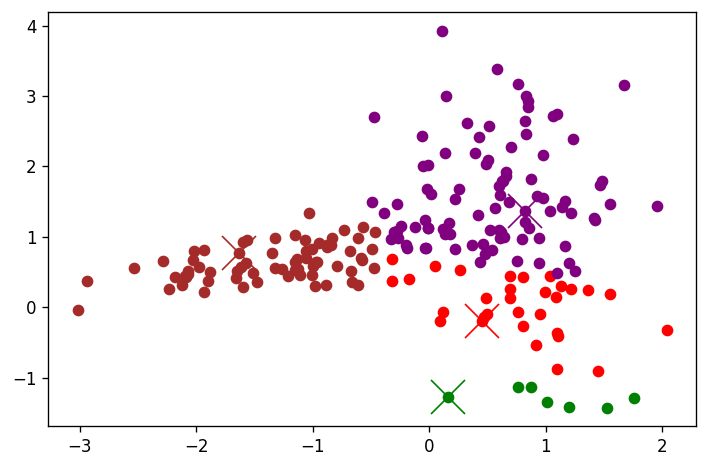

In [6]:
plot_points(Xc_2[:, 0], Xc_2[:, 1], centroids, closest_centroids)
print ('Cost= {}'.format(J(centroids, closest_centroids)))

### Compute new centroids

New centroids: [array([0.74612298, 0.04087703]), array([-1.35098183,  0.63527924]), array([ 1.04034126, -1.28521513]), array([0.54064508, 1.60185016])]
Cost= 0.619372590365275


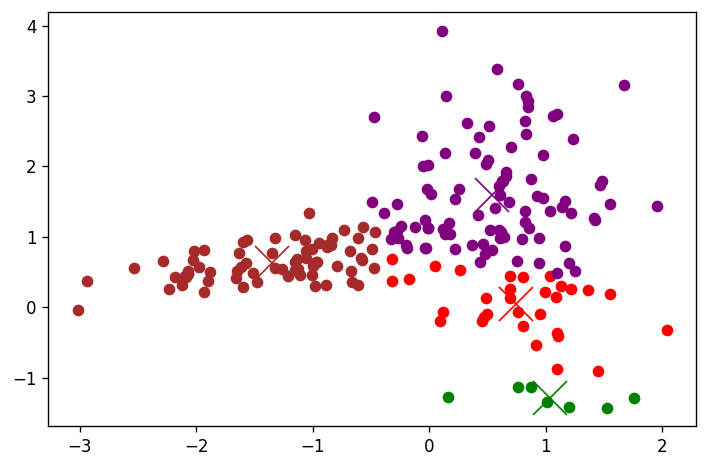

In [7]:
def compute_means(centroids, closest_centroids):      
    new_centroids= []
    for i in range (len(centroids)):
        if i not in closest_centroids: 
            new_centroids.append(centroids[i])
        else: 
            new_centroid= np.mean(points[np.where(closest_centroids==i)], axis = 0)
            new_centroids.append(new_centroid)
    return new_centroids

centroids = compute_means(centroids, closest_centroids)
print ('New centroids:',centroids)
print ('Cost= {}'.format(J(centroids, closest_centroids)))
plot_points(Xc_2[:, 0], Xc_2[:, 1], centroids=centroids, closest_centroids=closest_centroids)

### Iterate setps 2,3 till cost is stabile 

Iteration: 2 Cost: 0.5809662178968287
Iteration: 3 Cost: 0.5663521412607642
Iteration: 4 Cost: 0.5495659205621545
Iteration: 5 Cost: 0.5337576655982657
Iteration: 6 Cost: 0.5141555071972959
Iteration: 7 Cost: 0.4956226976874648
Iteration: 8 Cost: 0.4915803530815241
Iteration: 9 Cost: 0.4870365728925417
Iteration: 10 Cost: 0.47732773180723687
Iteration: 11 Cost: 0.4715492494065711
Iteration: 12 Cost: 0.46622939997881396
Iteration: 13 Cost: 0.46079140292574805
Iteration: 14 Cost: 0.45889126892203663
Iteration: 15 Cost: 0.45853337778784325
Iteration: 16 Cost: 0.45827195390915465
Iteration: 17 Cost: 0.4581469398652807


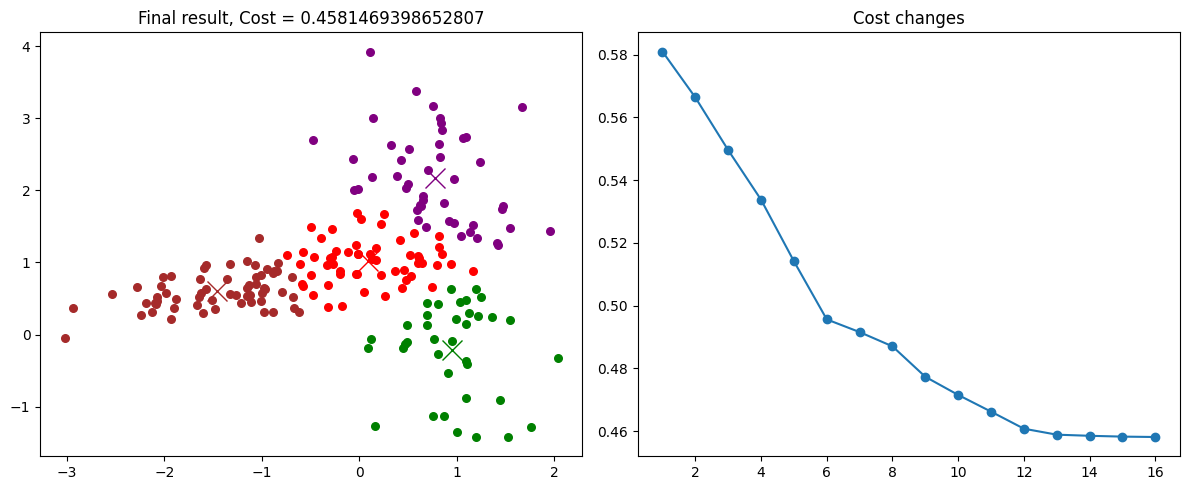

In [8]:
import numpy as np
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
cost_history = []

for iteration in range(20):
    closest_centroids = compute_closest_centroids(points, centroids)
    cost = J(centroids, closest_centroids)
    cost_history.append(cost)

    new_centroids = np.array(
        compute_means(centroids, closest_centroids),
        dtype=float
    )

    if np.allclose(new_centroids, centroids):
        break

    centroids = new_centroids

for i in range(len(points)):
    axs[0].scatter(points[i, 0], points[i, 1], color=colors[closest_centroids[i]], s=30)

for i, c in enumerate(centroids):
    axs[0].plot(c[0], c[1], marker='x', color=colors[i], markersize=14)

axs[0].set_title(f'Final result, Cost = {cost}')

axs[1].plot(range(1, len(cost_history) + 1),
            cost_history, marker='o')
axs[1].set_title('Cost changes')

for i, cost in enumerate(cost_history):
    print(f'Iteration: {i + 2} Cost: {cost}') # from 2 iter because we start code before

plt.tight_layout()
plt.show()

 #### K=4, 100 random init centroids

In [9]:
best_cost = 100
max_iters = 20

for run in range(100):
    indices = np.random.choice(len(points), size=4, replace=False)
    centroids = points[indices].copy()

    for iteration in range(max_iters):
        closest_centroids = compute_closest_centroids(points, centroids)
        new_centroids = np.array(compute_means(centroids, closest_centroids))

        if np.allclose(new_centroids, centroids):
            break

        centroids = new_centroids

    cost = J(centroids, closest_centroids)

    if cost < best_cost:
        best_cost = cost

print("Best cost:", best_cost)

Best cost: 0.4576916248652856


Text(0.5, 1.0, 'Best J in 100 random centroids is 0.4576916248652856')

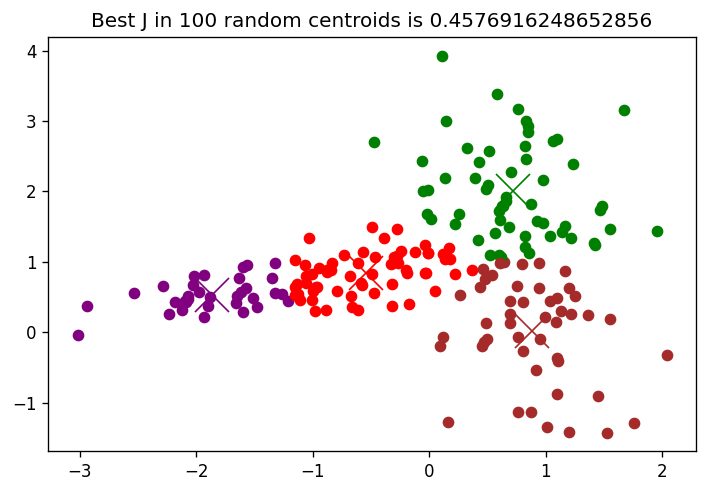

In [10]:
plot_points(Xc_2[:, 0], Xc_2[:, 1], centroids=centroids, closest_centroids=closest_centroids)
plt.title(f"Best J in 100 random centroids is {best_cost}")

### kmeans with sklearn

Text(0.5, 1.0, 'Sklearn kmeans Cost: 0.45769162486528564')

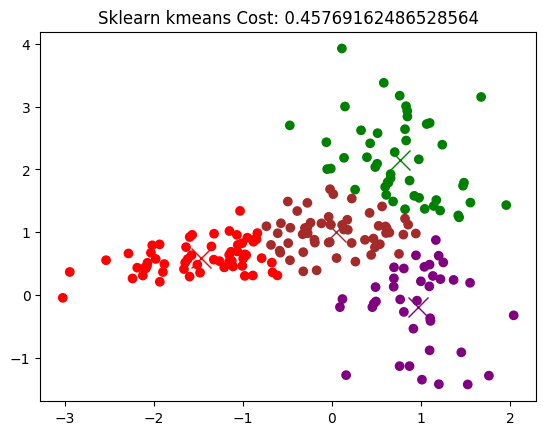

In [13]:
from sklearn.cluster import KMeans

X, y = np.array(list(zip(*points)))

clf = KMeans(n_clusters=4, n_init=10)
clf.fit(points)
predicted = clf.predict(points)

point_colors = [colors[label] for label in predicted]

plt.scatter(X, y, c=point_colors)

for i, c in enumerate(clf.cluster_centers_):
    plt.plot(c[0], c[1], marker='x', color=colors[i], markersize=14)

plt.title(f'Sklearn kmeans Cost: {clf.inertia_ / len(points)}')
